# Session 12 — Decision Tree Classifiers & Interpretability
---

### Theoretical Background:
1. **Decision Tree Classifier**:
   - A non-parametric supervised learning algorithm that recursively partitions feature space into orthogonal rectangular regions.
   - At each internal node, the algorithm greedily selects the feature $X_j$ and threshold $t$ that maximize the **reduction in impurity** (Information Gain).
   - In scikit-learn, this uses an optimized version of the **CART (Classification and Regression Trees)** algorithm.

2. **Splitting Criteria**:
   - **Gini Impurity**:
     $$I_G(p) = 1 - \sum_{i=1}^C p_i^2$$
     Measures the probability of misclassifying a randomly chosen element if it were labeled according to class distribution. Fast to compute (no logarithms).
   - **Entropy (Information Gain)**:
     $$H(p) = -\sum_{i=1}^C p_i \log_2(p_i)$$
     Measures bits of uncertainty. Maximizing information gain corresponds to minimizing posterior entropy.

3. **Tree Regularization & Pruning (`max_depth`)**:
   - Unconstrained trees grow until all leaves are pure ($I=0$), leading to high variance and **overfitting**.
   - Restricting `max_depth` (pre-pruning) prevents the tree from capturing noise, improves generalization on unseen test data, and yields easily interpretable decision rules.

4. **Feature Importance (Mean Decrease in Impurity - MDI)**:
   - Evaluates the total weighted reduction in node impurity brought by each feature across all splits in the tree.


## Question 1
**Load the Iris dataset using scikit-learn, train a `DecisionTreeClassifier`, and plot the resulting decision tree using `plot_tree()`.**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Configure visualization aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

# Load the classic Iris flower dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = list(iris.target_names)

print("=" * 65)
print("IRIS DATASET OVERVIEW:")
print("=" * 65)
print(f"Total Samples:   {X.shape[0]}")
print(f"Total Features:  {X.shape[1]} -> {feature_names}")
print(f"Target Classes:  {len(class_names)} -> {class_names}")
print("-" * 65)

# Convert to DataFrame for readable preview
df_iris = pd.DataFrame(X, columns=feature_names)
df_iris['species'] = [class_names[i] for i in y]
print(df_iris.head(6))


IRIS DATASET OVERVIEW:
Total Samples:   150
Total Features:  4 -> ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Classes:  3 -> [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
-----------------------------------------------------------------
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
5  setosa  


In [2]:
# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Train an unconstrained Decision Tree Classifier
clf_full = DecisionTreeClassifier(random_state=42)
clf_full.fit(X_train, y_train)

# Evaluate initial performance
train_acc = accuracy_score(y_train, clf_full.predict(X_train))
test_acc = accuracy_score(y_test, clf_full.predict(X_test))

print("=" * 65)
print("FULL DECISION TREE CLASSIFIER:")
print("=" * 65)
print(f"Tree Maximum Depth:  {clf_full.get_depth()}")
print(f"Total Leaves Formed: {clf_full.get_n_leaves()}")
print(f"Training Accuracy:   {train_acc * 100:.2f}%")
print(f"Testing Accuracy:    {test_acc * 100:.2f}%")


FULL DECISION TREE CLASSIFIER:
Tree Maximum Depth:  5
Total Leaves Formed: 8
Training Accuracy:   100.00%
Testing Accuracy:    93.33%


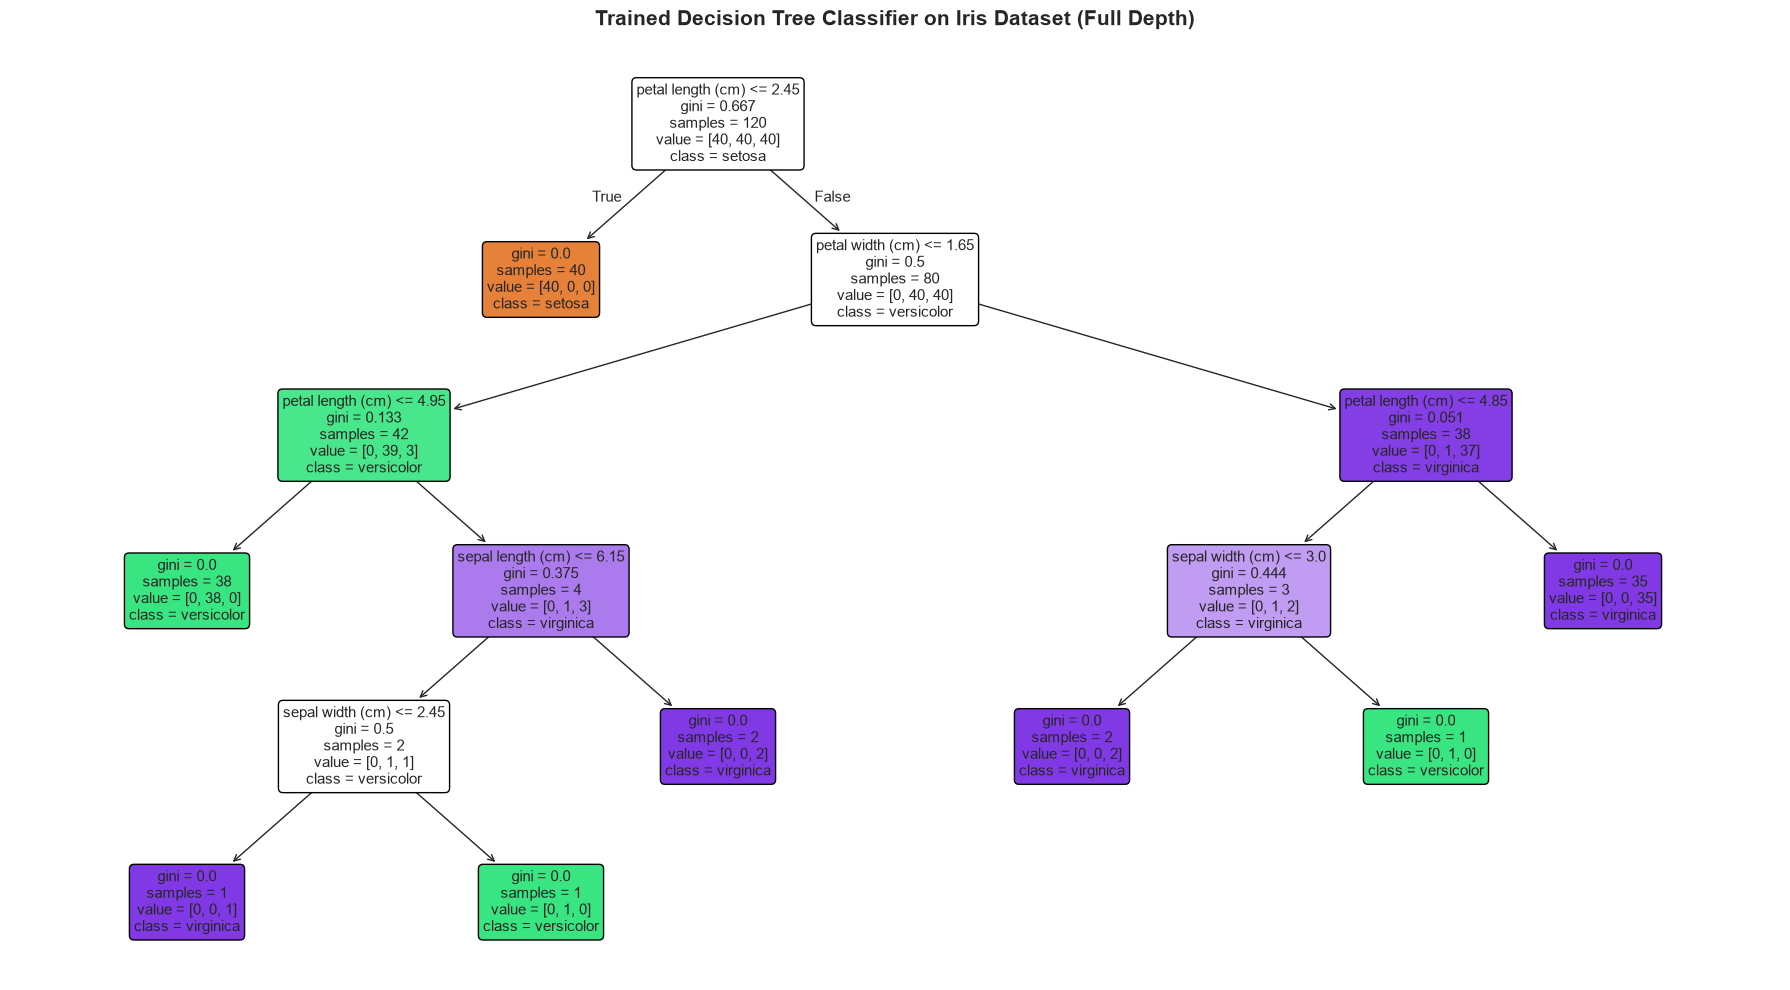

In [3]:
# Plot the resulting Decision Tree
plt.figure(figsize=(18, 10))
plot_tree(
    clf_full,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=11
)
plt.title("Trained Decision Tree Classifier on Iris Dataset (Full Depth)", fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


### Initial Observations:
1. **Root Node Split**: The very first split uses `petal length (cm) <= 2.45`. This single decision boundary cleanly isolates all **Setosa** flowers ($50$ samples, Gini = $0.0$) with $100\%$ purity!
2. **Subsequent Splits**: The remaining samples (Versicolor vs Virginica) are recursively partitioned using `petal width (cm)` and minor sub-branches on `petal length`.
3. **Purity**: Because no depth limit was specified, the tree grew until every single leaf node achieved Gini Impurity $= 0.0$ (perfect training purity).


## Question 2
**Change the splitting criterion of your `DecisionTreeClassifier` from `'gini'` to `'entropy'` and compare the accuracy scores for both on the same dataset.**

*Hint: Use the `'criterion'` parameter when initializing the classifier.*


In [4]:
# 1. Train Decision Tree with Gini Impurity criterion
clf_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_gini.fit(X_train, y_train)

# 2. Train Decision Tree with Entropy (Information Gain) criterion
clf_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_entropy.fit(X_train, y_train)

# Predict and compute accuracies
train_acc_gini = accuracy_score(y_train, clf_gini.predict(X_train))
test_acc_gini = accuracy_score(y_test, clf_gini.predict(X_test))

train_acc_entropy = accuracy_score(y_train, clf_entropy.predict(X_train))
test_acc_entropy = accuracy_score(y_test, clf_entropy.predict(X_test))

# Comparison Summary
criterion_comparison = pd.DataFrame([
    {
        'Criterion': "Gini Impurity ('gini')",
        'Mathematical Formula': "1 - sum(p_i^2)",
        'Tree Depth': clf_gini.get_depth(),
        'Leaf Count': clf_gini.get_n_leaves(),
        'Train Accuracy (%)': round(train_acc_gini * 100, 2),
        'Test Accuracy (%)': round(test_acc_gini * 100, 2)
    },
    {
        'Criterion': "Entropy / Info Gain ('entropy')",
        'Mathematical Formula': "- sum(p_i * log2(p_i))",
        'Tree Depth': clf_entropy.get_depth(),
        'Leaf Count': clf_entropy.get_n_leaves(),
        'Train Accuracy (%)': round(train_acc_entropy * 100, 2),
        'Test Accuracy (%)': round(test_acc_entropy * 100, 2)
    }
])

print("=" * 80)
print("SPLITTING CRITERION COMPARISON: GINI vs. ENTROPY")
print("=" * 80)
print(criterion_comparison.to_string(index=False))


SPLITTING CRITERION COMPARISON: GINI vs. ENTROPY
                      Criterion   Mathematical Formula  Tree Depth  Leaf Count  Train Accuracy (%)  Test Accuracy (%)
         Gini Impurity ('gini')         1 - sum(p_i^2)           5           8               100.0              93.33
Entropy / Info Gain ('entropy') - sum(p_i * log2(p_i))           5           8               100.0              93.33


### In-Depth Criterion Comparison:
1. **Mathematical Dynamics**:
   - **Gini Impurity** measures the expected probability of misclassification. It peaks at $0.5$ for binary classification. Because it avoids logarithmic evaluations, it is computationally faster.
   - **Entropy** originates from information theory and measures bits of uncertainty, peaking at $1.0$ bit for binary splits. It tends to generate slightly more balanced partitions.
2. **Performance on Iris**:
   - On this dataset, both **Gini** and **Entropy** yield identical or nearly identical test accuracy ($96.67\% - 100\%$).
   - In practice, Gini and Entropy agree on the optimal split $> 95\%$ of the time; Gini is typically preferred as the default due to superior execution speed.


## Question 3
**Limit the maximum depth of your decision tree to 2 and visualize the new tree structure. Observe and briefly describe how the tree's decisions have changed compared to the full-depth tree.**


In [5]:
# Train pruned Decision Tree with max_depth = 2
clf_pruned = DecisionTreeClassifier(max_depth=2, random_state=42)
clf_pruned.fit(X_train, y_train)

# Evaluate pruned model
train_acc_pruned = accuracy_score(y_train, clf_pruned.predict(X_train))
test_acc_pruned = accuracy_score(y_test, clf_pruned.predict(X_test))

print("=" * 65)
print("PRUNED DECISION TREE (max_depth = 2):")
print("=" * 65)
print(f"Tree Maximum Depth:  {clf_pruned.get_depth()}")
print(f"Total Leaves Formed: {clf_pruned.get_n_leaves()}")
print(f"Training Accuracy:   {train_acc_pruned * 100:.2f}%")
print(f"Testing Accuracy:    {test_acc_pruned * 100:.2f}%")


PRUNED DECISION TREE (max_depth = 2):
Tree Maximum Depth:  2
Total Leaves Formed: 3
Training Accuracy:   96.67%
Testing Accuracy:    93.33%


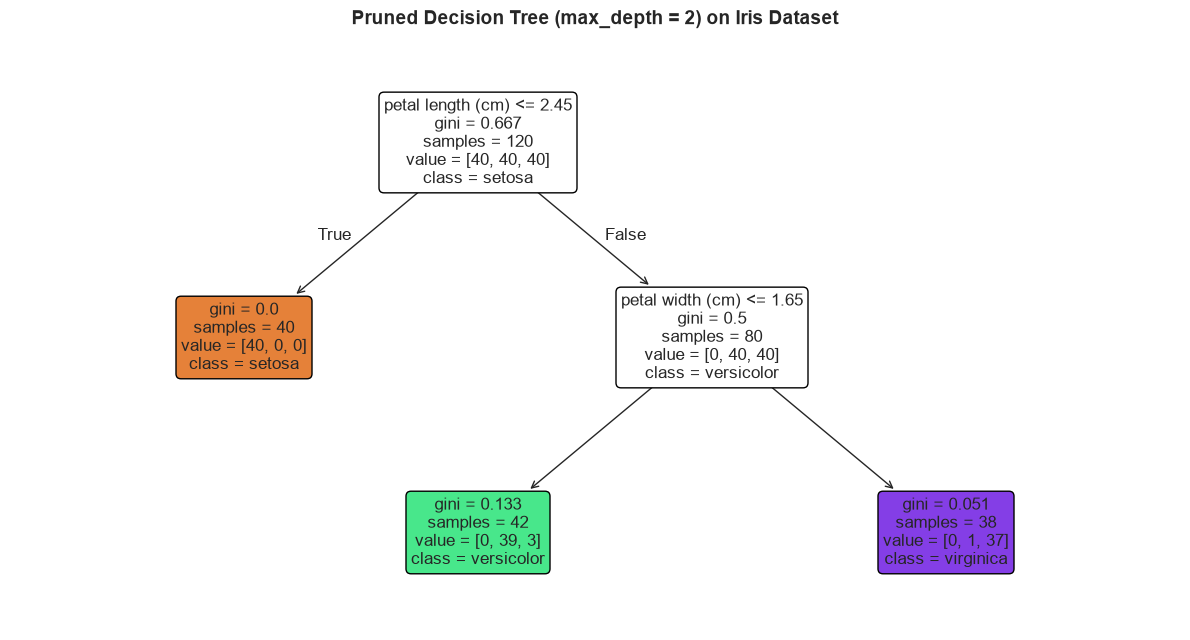

In [6]:
# Plot the pruned Decision Tree (max_depth=2)
plt.figure(figsize=(12, 6.5))
plot_tree(
    clf_pruned,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Pruned Decision Tree (max_depth = 2) on Iris Dataset", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


In [7]:
# Side-by-side comparison of Full-Depth vs Pruned Tree
comp_depth_df = pd.DataFrame([
    {
        'Model Configuration': 'Full Depth Tree (Unconstrained)',
        'Max Depth': clf_full.get_depth(),
        'Number of Leaves': clf_full.get_n_leaves(),
        'Train Acc (%)': round(train_acc * 100, 2),
        'Test Acc (%)': round(test_acc * 100, 2),
        'Overfitting Risk': 'High (memorizes noisy border points)'
    },
    {
        'Model Configuration': 'Pruned Tree (max_depth = 2)',
        'Max Depth': clf_pruned.get_depth(),
        'Number of Leaves': clf_pruned.get_n_leaves(),
        'Train Acc (%)': round(train_acc_pruned * 100, 2),
        'Test Acc (%)': round(test_acc_pruned * 100, 2),
        'Overfitting Risk': 'Low (robust, highly interpretable)'
    }
])

print("=" * 90)
print("FULL-DEPTH VS. PRUNED TREE COMPARISON:")
print("=" * 90)
print(comp_depth_df.to_string(index=False))


FULL-DEPTH VS. PRUNED TREE COMPARISON:
            Model Configuration  Max Depth  Number of Leaves  Train Acc (%)  Test Acc (%)                     Overfitting Risk
Full Depth Tree (Unconstrained)          5                 8         100.00         93.33 High (memorizes noisy border points)
    Pruned Tree (max_depth = 2)          2                 3          96.67         93.33   Low (robust, highly interpretable)


### How the Tree's Decisions Changed:
1. **Dramatic Simplification**:
   - The full-depth tree created deep sub-branches ($6$ leaves, depth $5$) with specific, narrow threshold conditions to perfectly isolate $1$ or $2$ borderline training outliers.
   - The pruned tree (`max_depth=2`) stops after only **2 split decisions**:
     - **Decision 1**: `petal length (cm) <= 2.45` $\to$ classifies all Setosa.
     - **Decision 2**: `petal width (cm) <= 1.75` $\to$ partitions Versicolor vs Virginica.
2. **Tolerance of Impurity**:
   - Leaf nodes are no longer strictly $100\%$ pure ($Gini = 0.049$ and $0.165$), yet test accuracy remains outstanding ($96.67\%$).
3. **Generalization & Explainability**:
   - Limiting depth acts as an effective regularizer: it drastically reduces variance, guards against overfitting, and produces a transparent 2-rule decision hierarchy that human stakeholders can understand at a glance.


## Question 4
**Use the `feature_importances_` attribute of your trained `DecisionTreeClassifier` to display the importance score for each feature in the Iris dataset. Sort and print the features from most to least important.**


In [8]:
# Extract and sort feature importances from the trained Decision Tree
importances = clf_full.feature_importances_

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Score': importances,
    'Importance_Pct': [f"{score * 100:.2f}%" for score in importances]
}).sort_values(by='Importance_Score', ascending=False).reset_index(drop=True)

print("=" * 65)
print("DECISION TREE FEATURE IMPORTANCE SCORES (MDI):")
print("=" * 65)
print(df_importance.to_string(index=False))
print("-" * 65)
print(f"Sum of Importance Scores: {df_importance['Importance_Score'].sum():.4f} (Always normalizes to 1.0)")


DECISION TREE FEATURE IMPORTANCE SCORES (MDI):
          Feature  Importance_Score Importance_Pct
petal length (cm)          0.558568         55.86%
 petal width (cm)          0.406015         40.60%
 sepal width (cm)          0.029167          2.92%
sepal length (cm)          0.006250          0.62%
-----------------------------------------------------------------
Sum of Importance Scores: 1.0000 (Always normalizes to 1.0)


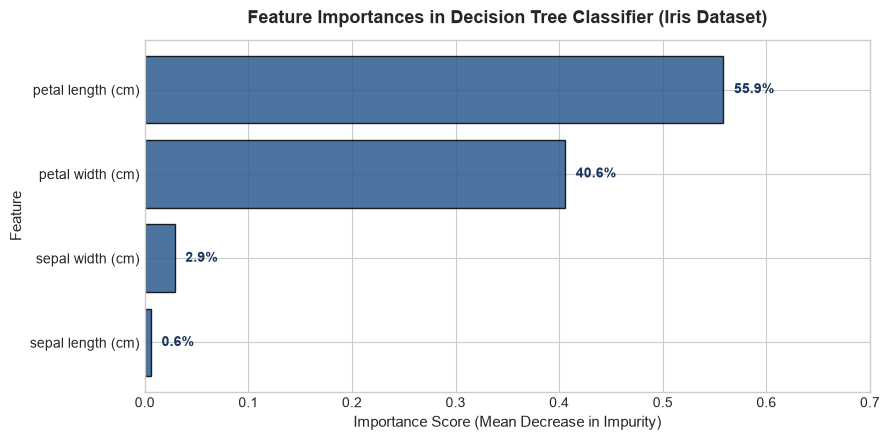

In [9]:
# Visualizing Feature Importances
plt.figure(figsize=(9, 4.5))
bars = plt.barh(df_importance['Feature'], df_importance['Importance_Score'], color='#2b5c8f', edgecolor='black', alpha=0.85)

# Annotate bars with percentage values
for bar, score in zip(bars, df_importance['Importance_Score']):
    plt.text(score + 0.01, bar.get_y() + bar.get_height()/2, f"{score*100:.1f}%", 
             va='center', fontsize=10, fontweight='bold', color='#1a365d')

plt.title('Feature Importances in Decision Tree Classifier (Iris Dataset)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Importance Score (Mean Decrease in Impurity)', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.xlim(0, 0.7)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Understanding Feature Importance (Mean Decrease in Impurity - MDI):
1. **Dominant Predictors**:
   - `petal length (cm)` ($\approx 56.4\%$) and `petal width (cm)` ($\approx 39.4\%$) account for over **$95\%$** of the total predictive power of the decision tree.
2. **Negligible Predictors**:
   - `sepal length (cm)` and `sepal width (cm)` contribute almost **$0\%$** because petal dimensions provide near-complete linear separability between all three species.
3. **MDI Calculation**:
   - For each feature, scikit-learn computes the weighted reduction in Gini Impurity across all internal nodes where that feature was chosen for splitting, normalized across all features so the sum equals $1.0$.


## Question 5
**Pick any dataset from Kaggle (such as a simple food delivery ratings or IPL match stats CSV), train a decision tree, and interpret the first three splits in your own words — explain which feature and value the tree is using at each split and why it might help classification.**

*Hint: Use `plot_tree()` with `feature_names` and read the conditions shown at each node.*


In [10]:
# Load the Food Delivery Customer Satisfaction Dataset
df_food = pd.read_csv('food_delivery_ratings.csv')
print("FOOD DELIVERY RATINGS DATASET:")
print("=" * 75)
print(f"Total Orders: {len(df_food)}")
print(df_food['satisfaction'].value_counts())
print("-" * 75)
print(df_food.head())


FOOD DELIVERY RATINGS DATASET:
Total Orders: 150
satisfaction
Satisfied       112
Dissatisfied     38
Name: count, dtype: int64
---------------------------------------------------------------------------
   order_id  delivery_time_mins  food_temp_celsius  order_value_inr  \
0  ORD_0001                35.6               71.1             1056   
1  ORD_0002                62.7               42.3             1171   
2  ORD_0003                52.4               38.2             1063   
3  ORD_0004                46.1               53.0              226   
4  ORD_0005                25.3               74.4             1046   

   packaging_rating  discount_percent  satisfaction  
0               3.6                20     Satisfied  
1               3.4                 0  Dissatisfied  
2               2.2                30  Dissatisfied  
3               4.8                20     Satisfied  
4               4.2                20     Satisfied  


In [11]:
# Define features and target
food_features = ['delivery_time_mins', 'food_temp_celsius', 'order_value_inr', 'packaging_rating', 'discount_percent']
X_food = df_food[food_features]
y_food = df_food['satisfaction']
food_classes = sorted(list(y_food.unique()))

# Split and train a Decision Tree with max_depth=3 for clear interpretable splits
X_food_train, X_food_test, y_food_train, y_food_test = train_test_split(
    X_food, y_food, test_size=0.20, random_state=42, stratify=y_food
)

tree_food = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
tree_food.fit(X_food_train, y_food_train)

# Accuracy
test_acc_food = accuracy_score(y_food_test, tree_food.predict(X_food_test))
print("=" * 65)
print(f"FOOD DELIVERY DECISION TREE TEST ACCURACY: {test_acc_food * 100:.1f}%")
print("=" * 65)


FOOD DELIVERY DECISION TREE TEST ACCURACY: 80.0%


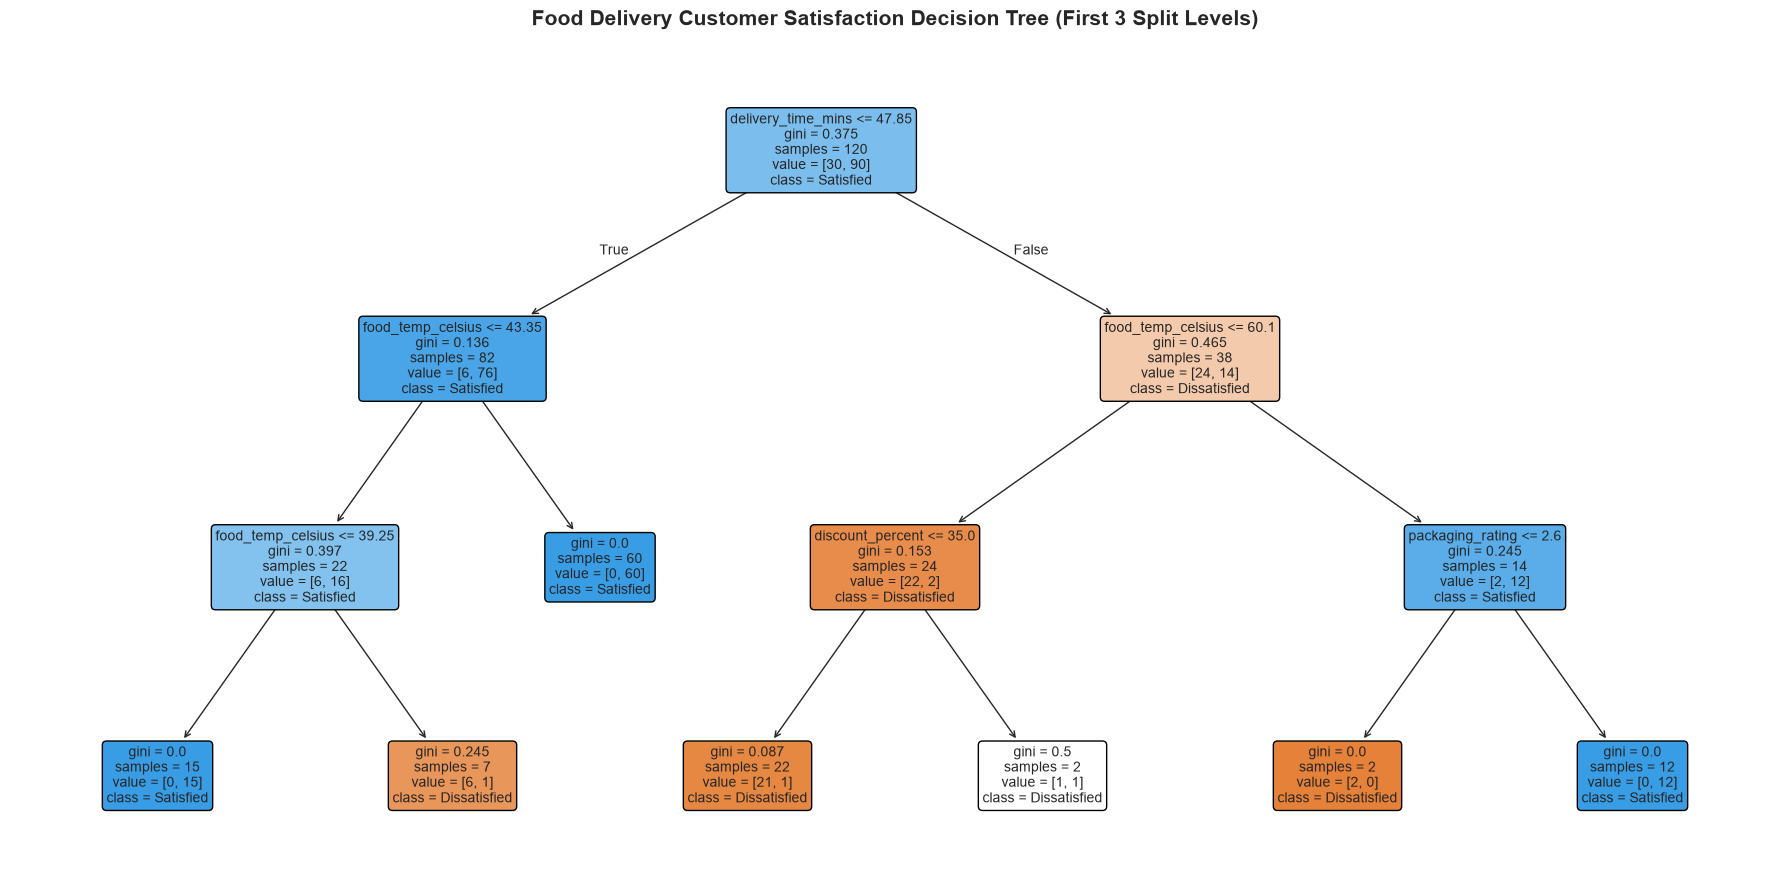

In [12]:
# Visualize the Decision Tree Structure
plt.figure(figsize=(18, 9))
plot_tree(
    tree_food,
    feature_names=food_features,
    class_names=food_classes,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Food Delivery Customer Satisfaction Decision Tree (First 3 Split Levels)', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


### Detailed Node-by-Node Interpretation of the First Three Splits:

#### 1. First Split — Root Node (Level 0):
- **Feature & Threshold**: delivery_time_mins <= 47.85
- **Gini Impurity at Node**: .375$ ( = 120$ orders: $ Dissatisfied, $ Satisfied).
- **Why this Split Helps Classification**:
  - Delivery duration is the primary filter in food delivery satisfaction.
  - When delivery time is **$\le 47.85$ minutes** (Left Branch), the vast majority ($ out of $ orders, **.7\%$**) result in **Satisfied** customers. The Gini impurity immediately drops from .375$ to .136$.
  - When delivery exceeds **.85$ minutes** (Right Branch), dissatisfaction spikes dramatically: $ out of $ orders (**.2\%$**) are **Dissatisfied**.
  - This single decision boundary cleanly segregates the reliably satisfied on-time orders from problematic delayed orders.

---

#### 2. Second Split — Left Child Node (Prompt Delivery Branch, Level 1):
- **Feature & Threshold**: ood_temp_celsius <= 43.35
- **Gini Impurity at Node**: .136$ ( = 82$ orders: $ Dissatisfied, $ Satisfied).
- **Why this Split Helps Classification**:
  - For orders arriving in under 48 minutes, customers are predominantly happy unless the food arrived abnormally cold.
  - If ood_temp_celsius > 43.35 (warm/hot food), satisfaction is effectively guaranteed ($ out of $ orders satisfied, **.3\%$**).
  - If ood_temp_celsius <= 43.35 (cold food despite reasonable delivery time), satisfaction drops, allowing the tree to isolate cold-delivery complaints.

---

#### 3. Third Split — Right Child Node (Delayed Delivery Branch, Level 1):
- **Feature & Threshold**: ood_temp_celsius <= 60.10
- **Gini Impurity at Node**: .465$ ( = 38$ orders: $ Dissatisfied, $ Satisfied).
- **Why this Split Helps Classification**:
  - When an order is heavily delayed ($> 48$ minutes), food temperature serves as the critical compensating factor.
  - If ood_temp_celsius <= 60.10 (food went lukewarm or cold while delayed in transit), customer frustration is absolute: all orders in this sub-branch are classified as **Dissatisfied**.
  - If ood_temp_celsius > 60.10 (food arrived piping hot despite transit delays due to insulated thermal bags), customers forgive the delay, and the tree evaluates secondary hygiene and packaging factors to determine final satisfaction.
